### Attention based
The previous GINE-based trajectory prediction model improved over the constant-velocity baseline, but interaction analysis revealed an important limitation.

Neighbor information was useful in low- and medium-density scenes, while performance degraded as the number of surrounding agents increased. In very dense scenes, removing neighbors could substantially improve prediction accuracy.

This notebook investigates whether attention-weighted message passing can address this limitation by allowing the model to learn which neighboring agents are most relevant.

The main comparison is between:

- the original GINE interaction model
- an attention-based GNN using `GATv2Conv`

Evaluation focuses on both overall ADE/FDE and performance across different interaction densities.

In [14]:
from pathlib import Path
import sys
import pickle

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATv2Conv

In [15]:
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "utils").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from utils.training_utils import (
    ade_loss,
    train_and_validate,
    evaluate_model,
    plot_losses,
)

from utils.graph_utils import (
    sample_to_graph,
)

from utils.analysis_utils import (
    evaluate_by_density,
    evaluate_neighbor_without_neighbors,
    neighbor_effect_by_count,
    bin_neighbor_effect,
)

#### Load datasets from data

In [16]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

train_path = PROCESSED_DIR / "nuscenes_train_prediction_samples.pkl"
val_path = PROCESSED_DIR / "nuscenes_val_prediction_samples.pkl"
test_path = PROCESSED_DIR / "nuscenes_test_prediction_samples.pkl"

with open(train_path, "rb") as f:
    train_dataset = pickle.load(f)

with open(val_path, "rb") as f:
    val_dataset = pickle.load(f)

with open(test_path, "rb") as f:
    test_dataset = pickle.load(f)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 25711
Validation samples: 6685
Test samples: 7242


Building the graph datasets required to train and evaluate the attention-based GNN

In [ ]:
from tqdm import tqdm

train_graphs = [sample_to_graph(sample) for sample in tqdm(train_dataset, desc="Train graphs")]
val_graphs = [sample_to_graph(sample) for sample in tqdm(val_dataset, desc="Validation graphs")]
test_graphs = [sample_to_graph(sample) for sample in tqdm(test_dataset, desc="Test graphs")]

print("\nTrain graphs:", len(train_graphs))
print("Validation graphs:", len(val_graphs))
print("Test graphs:", len(test_graphs))

Test graphs: 100%|██████████| 7242/7242 [00:02<00:00, 3499.96it/s]

Train graphs: 25711
Validation graphs: 6685
Test graphs: 7242


Create training, val and test DataLoaders

In [18]:
BATCH_SIZE = 64 

train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE,shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=BATCH_SIZE, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


### Attention based GNN

The original GINE model uses sum-based message aggregation. Our previous analysis showed that this can become problematic in very dense scenes, where many neighboring agents contribute messages simultaneously.

To address this, we replace the GINE interaction layers with `GATv2Conv`, which learns attention weights for neighboring agents.

The rest of the architecture is kept unchanged so the comparison remains fair

In [20]:
class GraphNetworkAttention(nn.Module): 
    def __init__(self):
        super().__init__()

        # -------------------
        # ENCODER
        # -------------------
        self.encoder = nn.Sequential(
            nn.Linear(15, 64),
            nn.ReLU()
        )
        
        # -------------------
        # ATTENTION LAYER 1
        # -------------------
        self.gat1 = GATv2Conv(
            in_channels=64,
            out_channels=64,
            heads=1,
            concat=False,
            edge_dim=3
        )
        
        # -------------------
        # ATTENTION LAYER 2
        # -------------------
        self.gat2 = GATv2Conv(
            in_channels=64,
            out_channels=64,
            heads=1,
            concat=False,
            edge_dim=3
        )
        
        # -------------------
        # DECODER
        # -------------------
        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 24)
        )
        
        
    def forward(self, batch):
        
        # Node encoding 
        h0 = self.encoder(batch.x)

        # Attention layers 
        h1 = self.gat1(h0, batch.edge_index, batch.edge_attr)
        h1 = torch.relu(h1)
        
        h2 = self.gat2(h1, batch.edge_index, batch.edge_attr)
        h2 = torch.relu(h2)
        
        # Keep only the prediction targets for the ego agent (first node in the batch)
        h_target = h2[batch.target_mask] 
        
        # Decode 12 future xy positions
        pred = self.decoder(h_target)
        
        pred = pred.view(-1, 12, 2)  # Reshape to (batch_size, 12, 2)
        
        return pred
    
# Test the model with a single batch
attention_model = GraphNetworkAttention().to(device)
batch = next(iter(train_loader)).to(device)
pred = attention_model(batch)
print("Prediction shape:", pred.shape)

Prediction shape: torch.Size([64, 12, 2])


#### Train the attention GNN

The attention model is trained using the same setup as the original GINE model, with the same loss function, optimizer, and training loop, lr = 0.001, 30 epochs

Epoch 1/30 | Train ADE: 6.2132 m | Val ADE: 4.9927 m
Epoch 2/30 | Train ADE: 4.4800 m | Val ADE: 4.2072 m
Epoch 3/30 | Train ADE: 4.2149 m | Val ADE: 4.0173 m
Epoch 4/30 | Train ADE: 4.0949 m | Val ADE: 4.2444 m
Epoch 5/30 | Train ADE: 3.9885 m | Val ADE: 3.9485 m
Epoch 6/30 | Train ADE: 3.9213 m | Val ADE: 3.8464 m
Epoch 7/30 | Train ADE: 3.9435 m | Val ADE: 3.8139 m
Epoch 8/30 | Train ADE: 3.8942 m | Val ADE: 3.9347 m
Epoch 9/30 | Train ADE: 3.8712 m | Val ADE: 3.8271 m
Epoch 10/30 | Train ADE: 3.8501 m | Val ADE: 3.7829 m
Epoch 11/30 | Train ADE: 3.8444 m | Val ADE: 3.7397 m
Epoch 12/30 | Train ADE: 3.8248 m | Val ADE: 3.7033 m
Epoch 13/30 | Train ADE: 3.8268 m | Val ADE: 3.7489 m
Epoch 14/30 | Train ADE: 3.8196 m | Val ADE: 3.7122 m
Epoch 15/30 | Train ADE: 3.8218 m | Val ADE: 3.8006 m
Epoch 16/30 | Train ADE: 3.7868 m | Val ADE: 3.7674 m
Epoch 17/30 | Train ADE: 3.7847 m | Val ADE: 3.7171 m
Epoch 18/30 | Train ADE: 3.7644 m | Val ADE: 3.7125 m
Epoch 19/30 | Train ADE: 3.7717 m | V

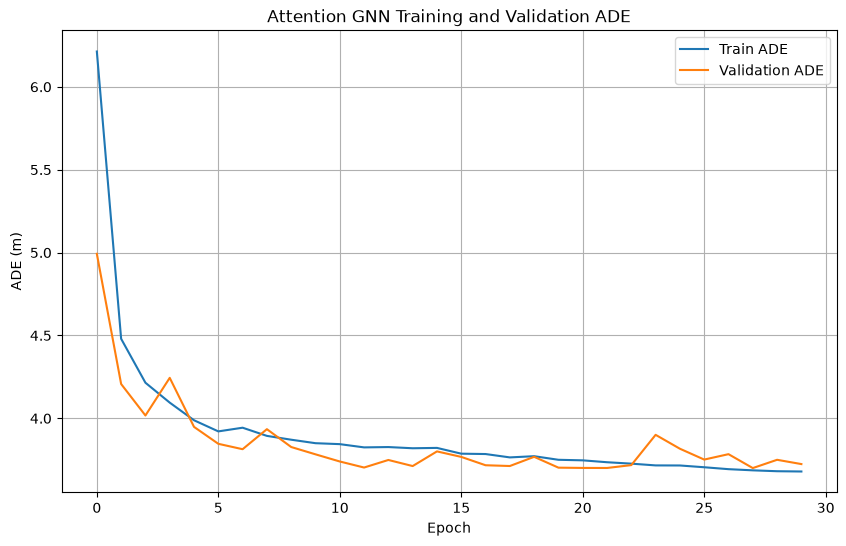

In [22]:
attention_model = GraphNetworkAttention().to(device)

optimizer = torch.optim.Adam(attention_model.parameters(), lr=0.001)

num_epochs = 30

checkpoint_path = (PROJECT_ROOT / "notebooks" / "best_attention_gnn_model.pth")

train_losses_attention, val_losses_attention = train_and_validate(
    attention_model,
    train_loader,
    val_loader,
    optimizer,
    criterion=ade_loss,
    num_epochs=num_epochs,
    checkpoint_path=checkpoint_path,
    device=device
)

plot_losses(
    train_losses_attention,
    val_losses_attention,
    title="Attention GNN Training and Validation ADE"
)

Load and evaluate attention GNN 

In [23]:
attention_model.load_state_dict(
    torch.load(checkpoint_path, map_location=device))

attention_model.eval()
attention_val_ade, attention_val_fde = evaluate_model(attention_model,val_loader,device)

print(f"Attention GNN Validation ADE: " f"{attention_val_ade:.3f} m")
print(f"Attention GNN Validation FDE: " f"{attention_val_fde:.3f} m")

Attention GNN Validation ADE: 3.700 m
Attention GNN Validation FDE: 8.945 m


### Interaction density analysis 

The original GINE model showed increasing difficulty in using neighbor information as scene density increased. We now evaluate the attention-based model separately on sparse, medium, and dense scenes to determine whether attention improves interaction modeling in dense environments.

In [24]:
attention_density = evaluate_by_density(
    attention_model,
    val_dataset,
    val_graphs,
    device
)

for bucket, metrics in attention_density.items():
    print(
        f"{bucket}: "
        f"ADE = {metrics['ade']:.3f} m, "
        f"FDE = {metrics['fde']:.3f} m, "
        f"n = {metrics['n']}"
    )

sparse: ADE = 4.101 m, FDE = 9.788 m, n = 1425
medium: ADE = 3.841 m, FDE = 9.326 m, n = 2144
dense: ADE = 3.420 m, FDE = 8.299 m, n = 3116


Compare with GINE, we now can confirm that dense scenes perform best with attention. 

#### Do neighbor interactions help?

To verify that the attention model is genuinely using interaction information, all neighbor nodes are removed at inference time while keeping the trained model unchanged.
If performance degrades after removing neighbors, this indicates that the model benefits from surrounding-agent information.

In [25]:
attention_ablated_ade, attention_ablated_fde = evaluate_neighbor_without_neighbors(attention_model, val_graphs, device)

print(
    f"Attention GNN with neighbors: "
    f"ADE = {attention_val_ade:.3f} m, "
    f"FDE = {attention_val_fde:.3f} m"
)

print(
    f"Attention GNN without neighbors: "
    f"ADE = {attention_ablated_ade:.3f} m, "
    f"FDE = {attention_ablated_fde:.3f} m"
)

Attention GNN with neighbors: ADE = 3.700 m, FDE = 8.945 m
Attention GNN without neighbors: ADE = 3.870 m, FDE = 9.370 m


So, removing neighbors makes performance worse, meaning that the attention model is benefiting from neighboro information

#### Effect of neighbor count

The original GINE model became increasingly worse at using neighbor information as the number of surrounding agents increased.

We now repeat the same analysis for the attention-based model.

For each sample:

\begin{equation}
\Delta ADE = ADE_{\text{full model}} - ADE_{\text{ablated model}}
\end{equation}

- $(\Delta ADE < 0)$: neighbors improve prediction
- $(\Delta ADE > 0)$: neighbors hurt prediction

In [26]:
neighbor_counts_attention, delta_ades_attention = neighbor_effect_by_count(attention_model, val_dataset, val_graphs, device)

attention_neighbor_effect = bin_neighbor_effect(neighbor_counts_attention, delta_ades_attention)

for bin_name, metrics in attention_neighbor_effect.items():
    print(
        f"{bin_name}: "
        f"mean ΔADE = {metrics['mean_delta_ade']:.3f} m, "
        f"n = {metrics['n']}"
    )

0-4: mean ΔADE = -0.156 m, n = 3569
5-9: mean ΔADE = -0.213 m, n = 1874
10-19: mean ΔADE = -0.156 m, n = 963
20-29: mean ΔADE = -0.069 m, n = 203
30-39: mean ΔADE = -0.130 m, n = 35
40+: mean ΔADE = -0.332 m, n = 41


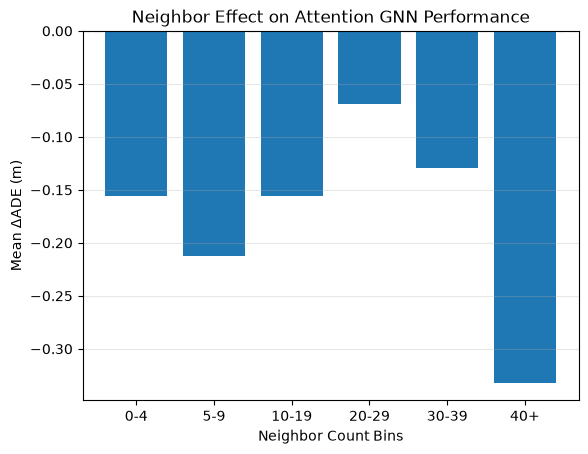

In [42]:
plt.bar(bin_names, mean_delta_ades)
plt.axhline(0, linestyle="--")

plt.xlabel("Neighbor Count Bins")
plt.ylabel("Mean ΔADE (m)")
plt.title("Neighbor Effect on Attention GNN Performance")
plt.grid(axis="y", alpha=0.3)

The bigger the bin means that that the full model (with attention) is better than the ablated model (without considering neighbors). 